# Chapter 11 — Symmetry suffices

*Companion notebook to **The Learned Kernel**, Ch. 11. Run top to bottom.*

A table such as Taiwan Credit is **unordered**: the rows are **exchangeable** and **similarity is
symmetric**, so a permutation-invariant operator factors through a symmetric statistic — the Gram
is symmetric. Bochner (Ch. 8) adds that the symmetric stationary class already contains every
stationary geometry, so symmetry loses no expressivity. Asymmetry is **extra capacity** that, on
an exchangeable table, does no work — and it carries a real cost: an asymmetric kernel has no
RKHS, so it **forfeits kernel ridge regression**.

**The frame** — *what is learned · how scored · what you read off.* What: the pairwise k and its
antisymmetric directional content Δ = k − kᵀ; and, when both are admitted, the asymmetry weight ρ.
Scored: the first-order risk change along k_s + εΔ is **−2⟨Δ, h_a⟩**. Read off: the earned weight
**ρ\*** — →0 exchangeable, >0 directed.

## Setup

In [1]:
try:
    import lkbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
        "learned-kernel[notebooks] @ git+https://github.com/asudjianto-xml/Learned-Kernel.git"],
        check=True)

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

from lkbook import set_style
from lkbook.chapters import ch11

set_style()

## 11.1  The first-order law and orthogonality

Any pairwise score splits into symmetric + antisymmetric parts. The directional content Δ = k − kᵀ
does predictive work only insofar as it aligns with the response gradient h_a; the first-order
gain is **−2⟨Δ, h_a⟩**, which vanishes when Δ ⊥ h_a. We verify the proportionality and then show
that on exchangeable Taiwan Credit the alignment over random directions concentrates at zero.

In [3]:
law = ch11.run_first_order(n_dirs=15)
ortho = ch11.run_orthogonality(n_dirs=30, n=800)
print(f"first-order law: corr(<Delta,h_a>, dL/deps) = {law['corr']:+.3f}  (predicts ~ -1)")
ti = ortho["taiwan_ips"]
print(f"Taiwan <Delta,h_a> over random directions: mean {ti.mean():+.4f} std {ti.std():.4f}"
      f"  (|mean|/std = {abs(ti.mean())/ti.std():.2f})")

first-order law: corr(<Delta,h_a>, dL/deps) = -0.990  (predicts ~ -1)
Taiwan <Delta,h_a> over random directions: mean -0.0003 std 0.0039  (|mean|/std = 0.07)


## 11.2  Asymmetrizing a sophisticated kernel forfeits KRR

Take a spectral (Bochner) kernel and asymmetrize its feature map (separate query/key transforms).
It is no longer symmetric PSD, so it leaves the RKHS — KRR's `(K+λI)⁻¹` solve no longer applies and
prediction drops to row-normalization (NW). Three arms on the **same** spectral kernel: the cost is
losing KRR, and asymmetry recovers none of it.

In [4]:
sc = ch11.run_spectral_cost(seeds=range(3))
print(f"spectral  sym + KRR : AUC {sc['sym_krr'].mean():.3f}")
print(f"spectral  sym + NW  : AUC {sc['sym_nw'].mean():.3f}   (cost of the predictor downgrade)")
print(f"spectral asym + NW  : AUC {sc['asym_nw'].mean():.3f}   (asymmetry recovers nothing)")
print(f"audit gain D {np.median(sc['D']):+.3f}   <Delta,h_a> {np.mean(sc['ip']):+.4f}")

spectral  sym + KRR : AUC 0.687
spectral  sym + NW  : AUC 0.619   (cost of the predictor downgrade)
spectral asym + NW  : AUC 0.613   (asymmetry recovers nothing)
audit gain D +0.012   <Delta,h_a> -0.0002


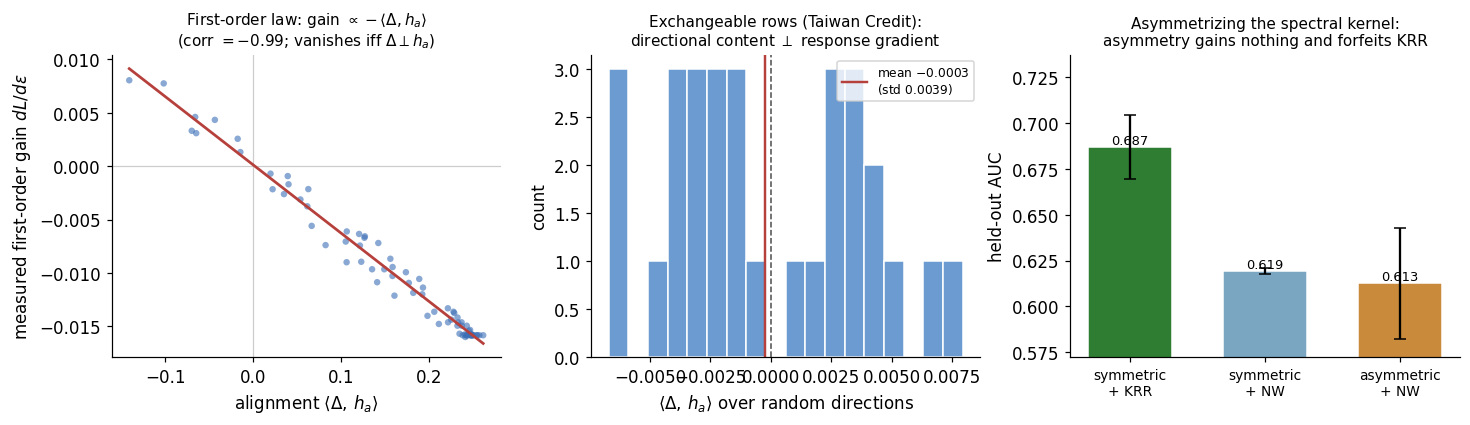

In [5]:
ch11.make_law_figure({"law": law, "ortho": ortho, "spectral_cost": sc})
plt.show()

## 11.3  The book's symmetric kernels beat asymmetric attention

Set the book's strongest **symmetric** kernels — spectral (Ch. 8), tree leaf (Ch. 4), and their
fusion (Ch. 10), each a PSD Gram + **KRR** — against the asymmetric attention smoother (W_Q ≠ W_K,
NW). The symmetric kernels, using the predictor symmetry unlocks, win. (A few seeds at a smaller
train size live; the book averages more — the ordering is the point.)

In [6]:
real = ch11.run_real_headtohead(seeds=range(2), n_train=700)
print(f"spectral + KRR   AUC {real['spectral_krr'].mean():.3f}")
print(f"tree     + KRR   AUC {real['tree_krr'].mean():.3f}")
print(f"fused    + KRR   AUC {real['fused_krr'].mean():.3f}")
print(f"attention + NW   AUC {real['asym_attn_nw'].mean():.3f}   (asymmetric, beaten by all three)")

spectral + KRR   AUC 0.705
tree     + KRR   AUC 0.734
fused    + KRR   AUC 0.741
attention + NW   AUC 0.630   (asymmetric, beaten by all three)


## 11.4  Use both, and read the diagnostic

Symmetry and asymmetry need not be an exclusive choice: fuse a symmetric PSD channel (KRR) and an
asymmetric channel (NW), choosing the asymmetry weight ρ leakage-free on a query fold (Ch. 10). The
earned **ρ\*** is the diagnostic — ρ*→0 on exchangeable data, ρ*>0 on a directed task.

In [7]:
fu = ch11.run_fusion_diagnostic(seeds=range(3))
print(f"earned asymmetry weight rho*:  Taiwan (exchangeable) {fu['taiwan_rho'].mean():.2f}"
      f"   directed (temporal) {fu['directed_rho'].mean():.2f}")

earned asymmetry weight rho*:  Taiwan (exchangeable) 0.17   directed (temporal) 0.58


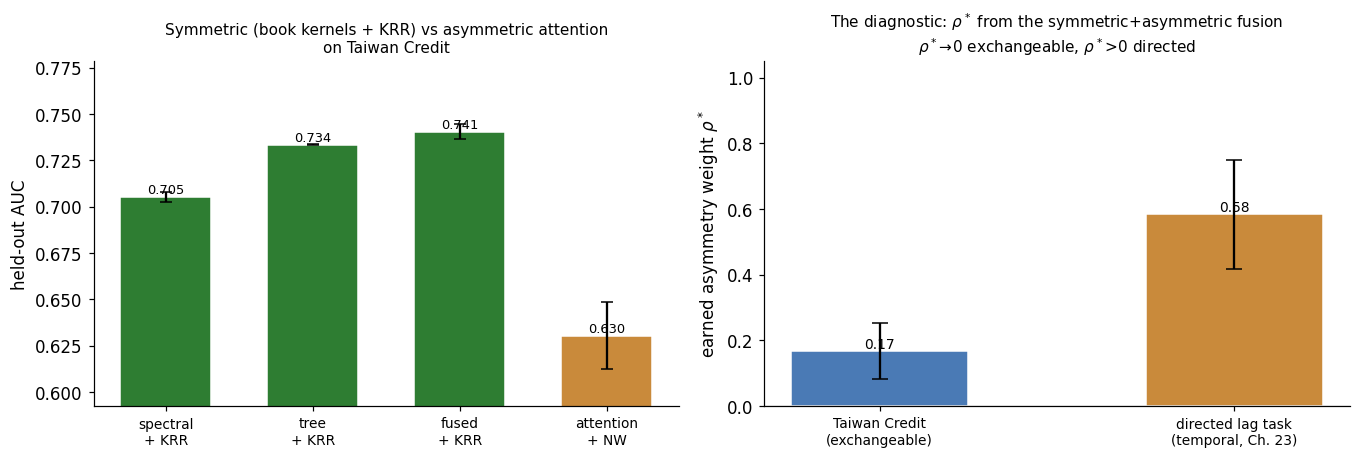

In [8]:
ch11.make_kernels_figure({"real": real, "fusion": fu})
plt.show()

## 11.5  When asymmetry is earned — and the decision rule

A directed mechanism makes asymmetry pay. Construct one: predict the **lagged** signal s(pos − δ)
by smoothing labels s(pos). A symmetric distance kernel centers its weight at the query's own
position and is wrong by the lag; the asymmetric smoother attends upstream and captures it. This is
a positional/temporal relation — the proper subject of **Ch. 23** (and the asymmetric-kernel theory
of Ch. 24).

In [9]:
di = ch11.run_directed_headtohead(seeds=range(3))
print(f"directed lag task — asymmetric RMSE {di['asym'].mean():.3f}, symmetric RMSE {di['sym'].mean():.3f}")
print(f"audit gain D (symmetrizing the trained asym model) median {np.median(di['D']):+.1f}")

directed lag task — asymmetric RMSE 0.189, symmetric RMSE 0.731
audit gain D (symmetrizing the trained asym model) median +26.9


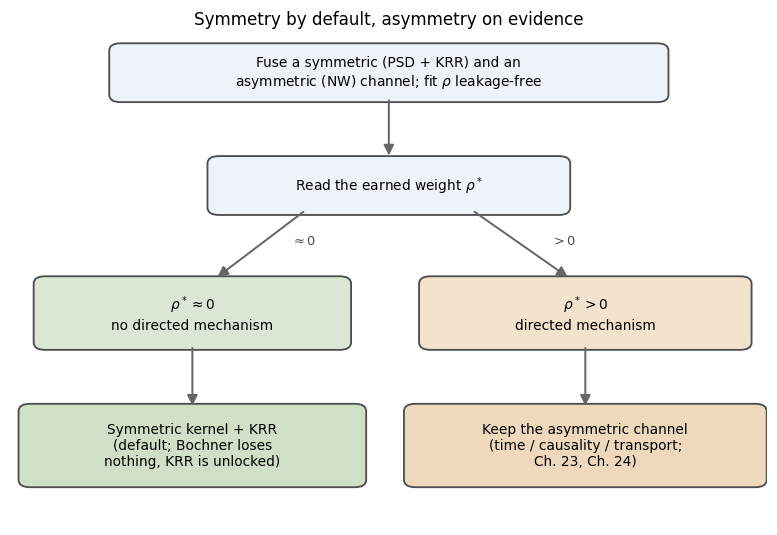

In [10]:
ch11.make_decision_figure()
plt.show()

### Explore: how directed must the data be before asymmetry is earned?

Sweep the lag δ. At δ = 0 the task is undirected and the two match; as δ grows the symmetric kernel
falls behind while the asymmetric one tracks the offset. (Capped at a moderate lag where the small
demo model converges reliably.)

In [11]:
from ipywidgets import interact, FloatSlider


def compare_at_lag(lag=0.12):
    r = ch11.directed_one_lag(lag, seed=0)
    fig, ax = plt.subplots(figsize=(5.6, 4.0), constrained_layout=True)
    ax.bar([0, 1], [r["sym"], r["asym"]], width=0.6,
           color=["#4a7ab5", "#c98a3b"], edgecolor="white")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["symmetric", "asymmetric"])
    ax.set_ylabel("held-out RMSE"); ax.set_ylim(0, max(r.values()) * 1.2 + 1e-3)
    for x, v in zip([0, 1], [r["sym"], r["asym"]]):
        ax.text(x, v, f" {v:.3f}", ha="center", va="bottom", fontsize=9)
    verdict = "matched (undirected)" if r["sym"] - r["asym"] < 0.05 else "asymmetry earned"
    ax.set_title(f"lag delta = {lag:.2f}: {verdict}", fontsize=10)
    plt.show()


interact(compare_at_lag, lag=FloatSlider(min=0.0, max=0.18, step=0.03, value=0.12,
         description="lag"));

interactive(children=(FloatSlider(value=0.12, description='lag', max=0.18, step=0.03), Output()), _dom_classes…

## Exercises

Fill in each `# TODO`; the solution is one click away.

**(easy)** Quantify the cost of asymmetrizing the spectral kernel: the AUC dropped by forfeiting
KRR, and the (non-)gain from the asymmetric part itself.

In [12]:
# TODO: from `sc`, compute (sym_krr - asym_nw) and (asym_nw - sym_nw)
krr_cost = asym_gain = None
print(krr_cost, asym_gain)

None None


<details><summary>Solution</summary>

```python
krr_cost  = sc["sym_krr"].mean() - sc["asym_nw"].mean()   # ~0.07: lost by leaving the RKHS
asym_gain = sc["asym_nw"].mean() - sc["sym_nw"].mean()    # ~0: asymmetry adds nothing
print(f"KRR forfeited: {krr_cost:+.3f}   asymmetry gain: {asym_gain:+.3f}")
```
Asymmetrizing the kernel costs the full KRR-vs-NW gap and returns nothing — the directional content
is orthogonal to the response gradient on an exchangeable table.
</details>

**(⋆)** Show the diagnostic separates the regimes. Compare the earned weight ρ* on exchangeable
Taiwan against the directed task and confirm the gap.

In [13]:
# TODO: compare fu["taiwan_rho"].mean() and fu["directed_rho"].mean()
gap = None
print(gap)

None


<details><summary>Solution</summary>

```python
gap = fu["directed_rho"].mean() - fu["taiwan_rho"].mean()
print(f"rho* directed {fu['directed_rho'].mean():.2f} vs Taiwan {fu['taiwan_rho'].mean():.2f}  (gap {gap:+.2f})")
```
The leakage-free fusion earns almost no asymmetric weight on the exchangeable table and substantial
weight on the directed task — the same "read the earned weight" diagnostic as Ch. 6 and Ch. 10.
</details>

---
*Companion to Chapter 11 of **The Learned Kernel**. Everything comes from `lkbook.chapters.ch11`
(which drives the real Ch. 8 spectral and Ch. 4 tree kernels via Ch. 10 for the symmetric arms).
The book averages over more seeds at a larger train size; here a few seeds run live, so absolute
numbers differ slightly but the orderings hold. The larger study (sixty-cell audit, head-to-head
against standard self-attention, TabPFN reverse-engineering) is summarized in the book.*